## 1. Importing Libraries and Loading Data

In [1]:
import ee
import geopandas as gpd

ee.Authenticate()
ee.Initialize()

## 2. Data Fetching

### 2.1 Fetching Data from Landsat and VIIRS

In [2]:
from spectral import get_spectral, get_viirs

cities = [
    {"code": "CAN", "name": "Ontario"},
    {"code": "IRN", "name": "Tehran"},
    {"code": "NGA", "name": "Lagos"},
	{"code": "FIN", "name": "Uusimaa"},
]

date_range = ("2025-01-01", "2025-12-31")

for city in cities:
    get_spectral(city['code'], city['name'], date_range)
    get_viirs(city['code'], date_range)


c:\Software Projects\Data Projects\uhi-modelling\uhenv\Lib\site-packages\geemap\conversion.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Sample points already exist at data/CAN_sample_points.csv.

VIIRS data already exists at data/CAN_viirs_features.csv.

Sample points already exist at data/IRN_sample_points.csv.

VIIRS data already exists at data/IRN_viirs_features.csv.

Sample points already exist at data/NGA_sample_points.csv.

VIIRS data already exists at data/NGA_viirs_features.csv.

Sample points already exist at data/FIN_sample_points.csv.

VIIRS data already exists at data/FIN_viirs_features.csv.



#### 2.1.1 Inspecting Class Balance of Sampled Points and Missingness

In [3]:
import pandas as pd

for city in cities:
    df = pd.read_csv(f"data/{city['code']}_sample_points.csv")
    urban = (df["LandCover"] == 50).sum()
    rural = (df["LandCover"] != 50).sum()
    print(f"{city['name']}: {urban} urban, {rural} rural, total: {len(df)}")
    
for city in cities:
    df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    print(f"{city['name']}: {len(df)} rows")
    print(df[["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())


for city in cities:
    df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    missing_months = set(range(1, 13)) - set(df["month"].unique())
    print(f"{city['name']}: missing months {missing_months}")



Ontario: 100 urban, 100 rural, total: 200
Tehran: 100 urban, 100 rural, total: 200
Lagos: 100 urban, 100 rural, total: 200
Uusimaa: 100 urban, 100 rural, total: 200
Ontario: 2400 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Tehran: 2400 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Lagos: 2229 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Uusimaa: 2198 rows
LST_day      0
LST_night    0
NDVI         0
NDBI         0
MNDWI        0
SAVI         0
Albedo       0
dtype: int64
Ontario: missing months set()
Tehran: missing months set()
Lagos: missing months set()
Uusimaa: missing months {6}


### 2.2 Fetching Met Data from Open-Meteo

In [4]:
from weather import process_city_weather

for city in cities:
    process_city_weather(city['code'], date_range)

Data has already been processed at data/CAN_Full_UHI_Data.csv.

Data has already been processed at data/IRN_Full_UHI_Data.csv.

Data has already been processed at data/NGA_Full_UHI_Data.csv.

Data has already been processed at data/FIN_Full_UHI_Data.csv.



#### 2.2.1 Inspecting Met Data for Missingness

In [5]:
for city in cities:
    df = pd.read_csv(f"data/{city['code']}_Full_UHI_Data.csv")
    print(f"{city['name']}: {len(df)} rows")

Ontario: 4800 rows
Tehran: 4800 rows
Lagos: 4800 rows
Uusimaa: 4800 rows


### 2.3 Concatenating Satellite and Met Data

The city column is added before concatenating.

In [6]:
viirs_dfs, weather_dfs = [], []

for city in cities:
    viirs_df = pd.read_csv(f"data/{city['code']}_viirs_features.csv")
    viirs_df["city"] = city["name"]
    viirs_dfs.append(viirs_df)

    weather_df = pd.read_csv(f"data/{city['code']}_Full_UHI_Data.csv")
    weather_df["city"] = city["name"]
    weather_dfs.append(weather_df)

viirs_data = pd.concat(viirs_dfs, ignore_index=True)
weather_data = pd.concat(weather_dfs, ignore_index=True)

weather_data["date"] = pd.to_datetime(weather_data["date"], utc=True)
weather_data["month"] = weather_data["date"].dt.month
weather_data["time"] = weather_data["date"].dt.hour.map({1: "night", 13: "day"})


uhi_data = weather_data.merge(
    viirs_data,
    on=["latitude", "longitude", "city", "month"],
    how="left"
)

print(uhi_data.shape)
print(uhi_data.head())
print(uhi_data[["LandCover", "Elevation", "LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())

(19200, 20)
                       date  humidity  precipitation  wind_speed  \
0 2025-01-01 01:00:00+00:00  96.11895            0.4   16.802786   
1 2025-01-01 13:00:00+00:00  88.68080            0.1   24.203810   
2 2025-02-01 01:00:00+00:00  86.77566            0.0   16.774803   
3 2025-02-01 13:00:00+00:00  80.08138            0.0   11.935778   
4 2025-03-01 01:00:00+00:00  74.14202            0.3   22.040997   

   cloud_cover_low  air_temperature   latitude  longitude  LandCover  \
0            100.0             1.20  43.431842 -80.482495       50.0   
1             65.0             0.35  43.431842 -80.482495       50.0   
2              0.0            -2.55  43.431842 -80.482495       50.0   
3              1.0           -15.65  43.431842 -80.482495       50.0   
4              1.0             2.80  43.431842 -80.482495       50.0   

    Elevation     city  month   time    Albedo   LST_day  LST_night     MNDWI  \
0  325.461426  Ontario      1  night  0.579363  5.272733   5.1836

#### 2.3.1 Inspecting Merge

In [7]:
print(uhi_data[uhi_data["LST_day"].isnull()]["city"].value_counts())
print(uhi_data[uhi_data["LST_day"].isnull()]["month"].value_counts())

uhi_data = uhi_data.sort_values(["city", "latitude", "longitude", "month", "time"]).reset_index(drop=True)

for col in ["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]:
    uhi_data[col] = uhi_data.groupby(["city", "latitude", "longitude"])[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

print(uhi_data[["LST_day", "LST_night", "NDVI", "NDBI", "MNDWI", "SAVI", "Albedo"]].isnull().sum())

city
Uusimaa    404
Lagos      342
Name: count, dtype: int64
month
6     426
3      48
8      36
7      30
12     28
4      28
9      28
2      26
10     26
5      26
11     26
1      18
Name: count, dtype: int64
LST_day      192
LST_night    192
NDVI         192
NDBI         192
MNDWI        192
SAVI         192
Albedo       192
dtype: int64


##### 2.3.1.1 Cleaning Missingness

In [8]:
null_mask = uhi_data["LST_day"].isnull()
print(uhi_data[null_mask]["city"].value_counts())
print(uhi_data[null_mask].groupby(["city", "latitude", "longitude"])["month"].apply(list))

null_pixels = uhi_data[uhi_data["LST_day"].isnull()][["city", "latitude", "longitude"]].drop_duplicates()

uhi_data = uhi_data.merge(
    null_pixels.assign(drop=True),
    on=["city", "latitude", "longitude"],
    how="left"
)
uhi_data = uhi_data[uhi_data["drop"].isnull()].drop(columns=["drop"])

print(uhi_data.shape)
print(uhi_data[["LST_day", "LST_night"]].isnull().sum())
print(uhi_data["city"].value_counts())

city
Lagos    192
Name: count, dtype: int64
city   latitude  longitude
Lagos  6.478715  3.496877     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.479197  3.438773     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.497516  3.556839     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.503954  3.539145     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.512168  3.415794     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.515417  3.518704     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.517941  3.572257     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
       6.577391  3.676986     [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, ...
Name: month, dtype: object
(19008, 20)
LST_day      0
LST_night    0
dtype: int64
city
Ontario    4800
Tehran     4800
Uusimaa    4800
Lagos      4608
Name: count, dtype: int64


In [9]:
lagos = uhi_data[uhi_data["city"] == "Lagos"]
print(lagos[["latitude", "longitude", "LandCover"]].drop_duplicates()["LandCover"].value_counts())
print(f"Urban: {(lagos['LandCover'] == 50).sum() // 24}")
print(f"Rural: {(lagos['LandCover'] != 50).sum() // 24}")

LandCover
50.0    100
10.0     40
80.0     23
30.0     14
90.0      7
20.0      5
40.0      1
60.0      1
95.0      1
Name: count, dtype: int64
Urban: 100
Rural: 92


### 2.4 Calculating Urban and Rural Temperatures and SUHI

In [10]:
uhi_data["is_urban"] = (uhi_data["LandCover"] == 50).astype(int)

urban = uhi_data[uhi_data["is_urban"] == 1].groupby(["city", "month", "time"]).agg(
    LST_day_urban=("LST_day", "mean"),
    LST_night_urban=("LST_night", "mean"),
    airtemp_urban=("air_temperature", "mean"),
    n_urban=("LST_day", "count")
).reset_index()

rural = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month", "time"]).agg(
    LST_day_rural=("LST_day", "mean"),
    LST_night_rural=("LST_night", "mean"),
    airtemp_rural=("air_temperature", "mean"),
    n_rural=("LST_day", "count")
).reset_index()

uhi_intensity = urban.merge(rural, on=["city", "month", "time"], how="inner")

uhi_intensity["SUHI_day"] = uhi_intensity["LST_day_urban"] - uhi_intensity["LST_day_rural"]
uhi_intensity["SUHI_night"] = uhi_intensity["LST_night_urban"] - uhi_intensity["LST_night_rural"]
uhi_intensity["AUHI"] = uhi_intensity["airtemp_urban"] - uhi_intensity["airtemp_rural"]

uhi_intensity = uhi_intensity.drop(columns=[
    "LST_day_urban", "LST_day_rural",
    "LST_night_urban", "LST_night_rural",
    "airtemp_urban", "airtemp_rural"
])

uhi_data["LST_day"] = uhi_data["LST_day"] / 0.02
uhi_data["LST_night"] = uhi_data["LST_night"] / 0.02

urban = uhi_data[uhi_data["is_urban"] == 1].groupby(["city", "month", "time"]).agg(
    LST_day_urban=("LST_day", "mean"),
    LST_night_urban=("LST_night", "mean"),
    airtemp_urban=("air_temperature", "mean"),
    n_urban=("LST_day", "count")
).reset_index()

rural = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month", "time"]).agg(
    LST_day_rural=("LST_day", "mean"),
    LST_night_rural=("LST_night", "mean"),
    airtemp_rural=("air_temperature", "mean"),
    n_rural=("LST_day", "count")
).reset_index()

uhi_intensity = urban.merge(rural, on=["city", "month", "time"], how="inner")
uhi_intensity["SUHI_day"] = uhi_intensity["LST_day_urban"] - uhi_intensity["LST_day_rural"]
uhi_intensity["SUHI_night"] = uhi_intensity["LST_night_urban"] - uhi_intensity["LST_night_rural"]
uhi_intensity["AUHI"] = uhi_intensity["airtemp_urban"] - uhi_intensity["airtemp_rural"]

uhi_intensity = uhi_intensity.drop(columns=[
    "LST_day_urban", "LST_day_rural",
    "LST_night_urban", "LST_night_rural",
    "airtemp_urban", "airtemp_rural"
])

uhi_intensity_wide = uhi_intensity.groupby(["city", "month"]).agg(
    n_urban=("n_urban", "first"),
    n_rural=("n_rural", "first"),
    SUHI_day=("SUHI_day", "mean"),
    SUHI_night=("SUHI_night", "mean"),
    AUHI_day=("AUHI", lambda x: x[uhi_intensity.loc[x.index, "time"] == "day"].values[0]),
    AUHI_night=("AUHI", lambda x: x[uhi_intensity.loc[x.index, "time"] == "night"].values[0])
).reset_index()

uhi_data_model = uhi_data.merge(
    uhi_intensity_wide[["city", "month", "SUHI_day", "SUHI_night", "AUHI_day", "AUHI_night"]],
    on=["city", "month"],
    how="left"
)

# Compute mean rural LST per city per month
rural_means = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "month"]).agg(
    rural_mean_LST_day=("LST_day", "mean"),
    rural_mean_LST_night=("LST_night", "mean"),
    rural_mean_airtemp=("air_temperature", "mean")
).reset_index()

# Merge back onto full dataset
uhi_data = uhi_data.merge(rural_means, on=["city", "month"], how="left")

# Compute pixel-level SUHI and AUHI
uhi_data["SUHI_day"] = uhi_data["LST_day"] - uhi_data["rural_mean_LST_day"]
uhi_data["SUHI_night"] = uhi_data["LST_night"] - uhi_data["rural_mean_LST_night"]
uhi_data["AUHI"] = uhi_data["air_temperature"] - uhi_data["rural_mean_airtemp"]

print(uhi_data[["SUHI_day", "SUHI_night", "AUHI"]].describe())
print(uhi_data[["SUHI_day", "SUHI_night", "AUHI"]].isnull().sum())

           SUHI_day    SUHI_night          AUHI
count  19008.000000  19008.000000  19008.000000
mean       1.618057      1.020448      0.629097
std        5.142381      2.943498      4.536121
min      -37.308680    -18.307601    -22.360505
25%       -1.194788     -0.659445     -1.843040
50%        1.257782      0.829390      0.160970
75%        4.783755      2.896015      2.353266
max       52.101830     13.251053     14.637495
SUHI_day      0
SUHI_night    0
AUHI          0
dtype: int64


## 3. Modelling 

### 3.1 Selecting and Encoding Features

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Step 1 — Select relevant columns
features = ["humidity", "precipitation", "wind_speed", "cloud_cover_low",
            "air_temperature", "latitude", "longitude", "Elevation",
            "Albedo", "MNDWI", "NDBI", "SAVI", "LandCover", "month"]

targets = ["SUHI_day", "SUHI_night", "AUHI"]

model_df = uhi_data[features + targets].copy()

# Re-encode
model_df["LandCover"] = model_df["LandCover"].astype(int).astype(str)
model_df = pd.get_dummies(model_df, columns=["LandCover"], prefix="LC")
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)
model_df = model_df.drop(columns=["month"])

# Add lat/lon back from uhi_data for pixel-level split
model_df["latitude"] = uhi_data["latitude"]
model_df["longitude"] = uhi_data["longitude"]



### 3.2 Implementing an 80-20 Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in model_df.columns if c not in targets]

# Pixel-level train/test split
unique_pixels = uhi_data[["latitude", "longitude"]].drop_duplicates().reset_index(drop=True)
train_pixels, test_pixels = train_test_split(unique_pixels, test_size=0.2, random_state=42)

train_mask = model_df[["latitude", "longitude"]].apply(tuple, axis=1).isin(
    train_pixels.apply(tuple, axis=1)
)

feature_cols = [c for c in model_df.columns if c not in targets + ["latitude", "longitude"]]

X_train = model_df[train_mask][feature_cols]
X_test = model_df[~train_mask][feature_cols]
y_train = model_df[train_mask][targets]
y_test = model_df[~train_mask][targets]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (15192, 22), X_test: (3816, 22)
y_train: (15192, 3), y_test: (3816, 3)


### 3.3 Tuning Hyperparameters & Training the Four Models

In [13]:
import os
import json
import joblib

from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

from model_cache import hash_data, hash_dict

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

FORCE_RETRAIN = False

def get_paths(name):
    base = name.lower().replace(" ", "_")
    return (
        os.path.join(MODEL_DIR, f"{base}.pkl"),
        os.path.join(MODEL_DIR, f"{base}_meta.json")
    )

rf_params = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [5, 10, 15, None],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__min_samples_leaf": [1, 2, 4],
    "estimator__max_features": ["sqrt", "log2"]
}

gb_params = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [3, 5, 7],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__min_samples_split": [2, 5, 10],
    "estimator__subsample": [0.8, 0.9, 1.0]
}

xgb_params = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [3, 5, 7],
    "estimator__learning_rate": [0.01, 0.05, 0.1],
    "estimator__subsample": [0.8, 0.9, 1.0],
    "estimator__colsample_bytree": [0.8, 0.9, 1.0],
    "estimator__reg_alpha": [0, 0.1, 0.5],
    "estimator__reg_lambda": [1, 1.5, 2]
}

current_data_hash = hash_data(X_train, y_train)

tuned_models = {}
best_params_log = {}

search_configs = [
    ("Random Forest",
     MultiOutputRegressor(RandomForestRegressor(random_state=42)),
     rf_params),

    ("Gradient Boosting",
     MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
     gb_params),

    ("XGBoost",
     MultiOutputRegressor(XGBRegressor(random_state=42, verbosity=0)),
     xgb_params)
]

for name, base_model, params in search_configs:
    model_path, meta_path = get_paths(f"tuned_{name}")

    current_param_hash = hash_dict(params)

    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)

        if (
            meta.get("param_hash") == current_param_hash and
            meta.get("data_hash") == current_data_hash
        ):
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}...")
        model = joblib.load(model_path)
        tuned_models[name] = model

    else:
        print(f"Tuning {name}...")

        grid_search = GridSearchCV(
            base_model,
            params,
            cv=5,
            scoring="r2",
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(X_train, y_train)

        model = grid_search.best_estimator_
        tuned_models[name] = model

        best_params_log[name] = grid_search.best_params_

        # Save model
        joblib.dump(model, model_path)

        # Save metadata
        meta = {
            "param_hash": current_param_hash,
            "data_hash": current_data_hash
        }

        with open(meta_path, "w") as f:
            json.dump(meta, f, indent=4)

        print(f"Saved {name}")

Loading cached Random Forest...
Loading cached Gradient Boosting...
Loading cached XGBoost...


In [14]:
linear_models = {
    "Linear Regression": MultiOutputRegressor(LinearRegression()),
    "Ridge Regression": MultiOutputRegressor(Ridge(alpha=1.0))
}

for name, model in linear_models.items():
    model_path, meta_path = get_paths(name)

    use_cache = False

    if os.path.exists(model_path) and os.path.exists(meta_path) and not FORCE_RETRAIN:
        with open(meta_path, "r") as f:
            meta = json.load(f)

        if meta.get("data_hash") == current_data_hash:
            use_cache = True

    if use_cache:
        print(f"Loading cached {name}...")
        tuned_models[name] = joblib.load(model_path)
    else:
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        tuned_models[name] = model

        joblib.dump(model, model_path)

        with open(meta_path, "w") as f:
            json.dump({"data_hash": current_data_hash}, f, indent=4)

Loading cached Linear Regression...
Loading cached Ridge Regression...


### Visualizing Performance

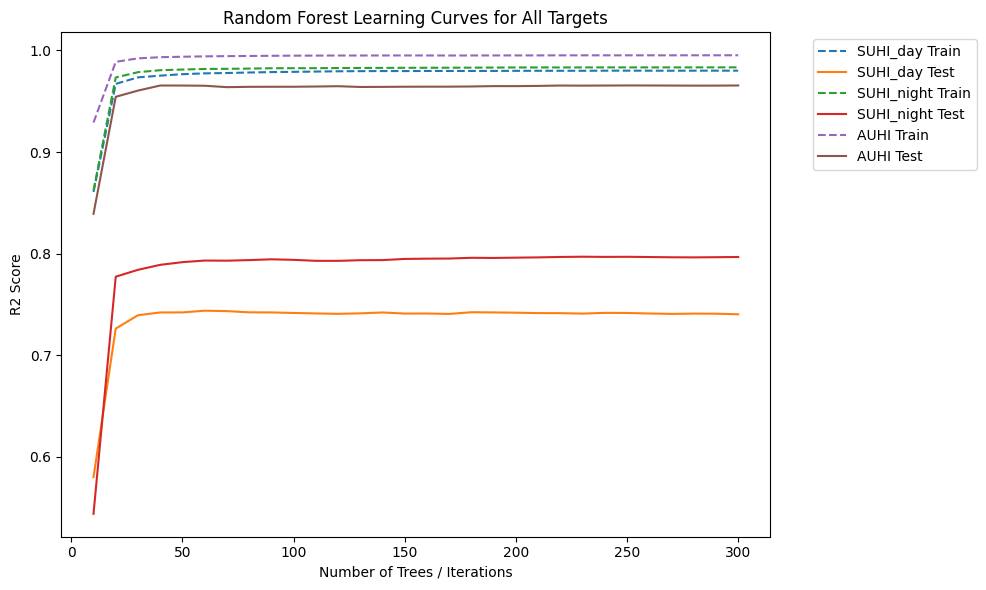

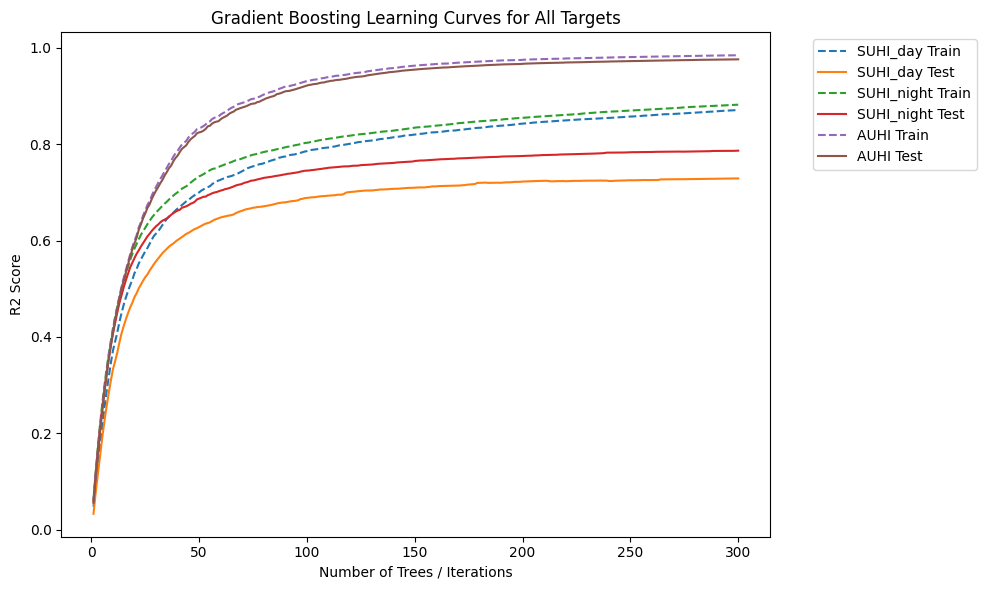

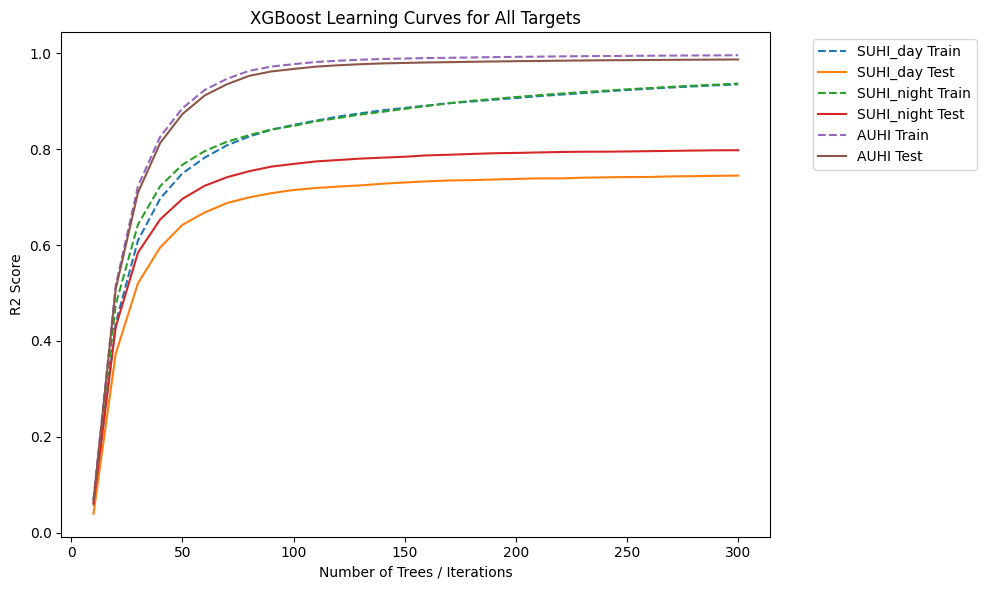

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from model_plots import plot_ensemble_learning_curves

# Call the function
plot_ensemble_learning_curves(tuned_models, X_train, y_train, X_test, y_test, targets, max_trees=300, step=10)

In [16]:
tuned_results = {}

for name, model in tuned_models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    model_results = {}

    for i, target in enumerate(targets):
        r2_train = r2_score(y_train.iloc[:, i], y_pred_train[:, i])
        r2_test = r2_score(y_test.iloc[:, i], y_pred_test[:, i])
        mae_train = mean_absolute_error(y_train.iloc[:, i], y_pred_train[:, i])
        mae_test = mean_absolute_error(y_test.iloc[:, i], y_pred_test[:, i])
        rmse_test = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred_test[:, i]))

        model_results[target] = {
            "R2_train": round(r2_train, 3),
            "R2_test": round(r2_test, 3),
            "R2_gap": round(r2_train - r2_test, 3),
            "MAE_train": round(mae_train, 3),
            "MAE_test": round(mae_test, 3),
            "MAE_gap": round(mae_test - mae_train, 3),
            "RMSE_test": round(rmse_test, 3)
        }

    tuned_results[name] = model_results


df_results = pd.DataFrame([
    {"model": model, "target": target, **metrics}
    for model, targets_dict in tuned_results.items()
    for target, metrics in targets_dict.items()
])

display(df_results)

,model,target,R2_train,R2_test,R2_gap,MAE_train,MAE_test,MAE_gap,RMSE_test
0,Random Forest,SUHI_day,0.980,0.740,0.240,0.471,1.660,1.189,2.793
1,Random Forest,SUHI_night,0.983,0.797,0.187,0.268,1.003,0.735,1.448
2,Random Forest,AUHI,0.995,0.966,0.030,0.168,0.430,0.262,0.861
3,Gradient Boosting,SUHI_day,0.871,0.729,0.142,1.330,1.832,0.502,2.851
4,Gradient Boosting,SUHI_night,0.882,0.787,0.095,0.747,1.081,0.334,1.484
5,Gradient Boosting,AUHI,0.985,0.976,0.008,0.392,0.466,0.074,0.713
6,XGBoost,SUHI_day,0.937,0.746,0.191,0.933,1.721,0.789,2.763
7,XGBoost,SUHI_night,0.938,0.798,0.141,0.540,1.035,0.496,1.445
8,XGBoost,AUHI,0.996,0.987,0.009,0.197,0.312,0.115,0.522
9,Linear Regression,SUHI_day,0.481,0.491,-0.011,2.779,2.865,0.086,3.907
